<a href="https://colab.research.google.com/github/penmalik/House-Price-Prediction-Analysis/blob/main/notebook/house_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSE PRICE PREDICTION ANALYSIS WITH MULTIPLE LINEAR REGRESSION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# read the dataset in
df = pd.read_csv('/content/Housing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Checking the uniqueness of each feature column with (Yes, No) data points

In [ ]:
cols_unique = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in cols_unique:
  print(col, df[col].unique())

mainroad ['yes' 'no']
guestroom ['no' 'yes']
basement ['no' 'yes']
hotwaterheating ['no' 'yes']
airconditioning ['yes' 'no']
prefarea ['yes' 'no']


convert the (yes, no) into (1,0)

In [ ]:
for col in cols_unique:
  df[col] = df[col].map({'yes':1, 'no':0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    int64 
 6   guestroom         545 non-null    int64 
 7   basement          545 non-null    int64 
 8   hotwaterheating   545 non-null    int64 
 9   airconditioning   545 non-null    int64 
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    int64 
 12  furnishingstatus  545 non-null    object
dtypes: int64(12), object(1)
memory usage: 55.5+ KB


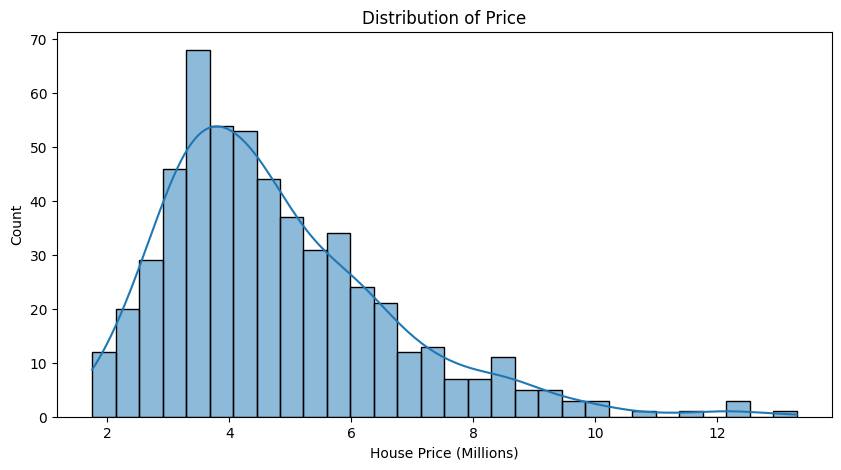

In [ ]:
# Histogram for House price
plt.figure(figsize=(10,5))
ax = sns.histplot(data=df, x=df['price']/1e6, bins=30, kde=True)
ax.set(title='Distribution of Price', xlabel='House Price (Millions)', ylabel='Count')
plt.show()

SPLITTING THE DATA INTO TRAINING AND TEST SET

In [ ]:
# splitting data into training and test set

# multiple features
x = df[['area', 'bedrooms', 'bathrooms', 'stories',
        'parking', 'mainroad', 'guestroom', 'basement',
        'hotwaterheating', 'airconditioning', 'prefarea']]

# target variable
y = df['price']

# splitting the data into 80% training set and 20% test set
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Coefficient of the slope
coeffients = pd.DataFrame({
    'Features': x_train.columns,
    'Coeffient': model.coef_
})

# intercept
intercept = model.intercept_

display(coeffients)
print(f"Intercept => {intercept}")


,Features,Coeffient
0,area,2.377105e+02
1,bedrooms,7.848365e+04
2,bathrooms,1.109326e+06
3,stories,4.269096e+05
4,parking,2.474431e+05
5,mainroad,4.126778e+05
6,guestroom,2.436064e+05
7,basement,4.350055e+05
8,hotwaterheating,7.122647e+05
9,airconditioning,8.084154e+05


Intercept => -72427.55025564972


In [ ]:
y_pred = model.predict(x_train)
print(y_pred)

[ 6984113.26040383  6918528.98606372  4678863.69633127  4231064.01530392
  3430260.80541857  4164781.5451748   3454031.85639498  2905877.63322185
  2455178.50670896  3542954.11131055  4015095.57741798  3863824.12016179
  4518239.81634087  3822478.41111438  3981909.70387542  6145372.36814096
  2269764.3090929   6004815.45571273  3464021.91014814  7732250.21025926
  6367982.63394256  3251977.92309543  5010266.02418191  7154316.01110429
  6300495.84969745  3406489.75444215  2484853.14109908  3062778.88158691
  5539549.38051709  2961462.71317626  4012375.08173596  2492217.43148669
  3722639.99701342  5188507.09837539  4359875.81723673  4206351.45922127
  2554977.74147952  6866920.26552254  5124803.21142064  6655974.59922803
  6950658.75946262  5380364.90485148  4634212.97507634  3860240.35548689
  3972201.58835049  3200844.34606473  7134911.4690843   7899984.25247957
  3846229.22425948  7345657.44024444  3877498.30676549  3720452.9363375
  6814177.44114462  5173127.25198813  5010702.166733

In [ ]:
result_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_pred
})
# to avoid the Predicted values being display in scientific notation
result_df['Predicted'] = result_df['Predicted'].round(0).astype(int)
display(result_df.head())

,Actual,Predicted
46,7525000,6984113
93,6300000,6918529
335,3920000,4678864
412,3430000,4231064
471,3010000,3430261


In [ ]:
y_pred_test = model.predict(x_test)

In [ ]:
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test
})

test_df['Predicted'] = test_df['Predicted'].round(0).astype(int)
display(test_df.head())

,Actual,Predicted
316,4060000,5398919
77,6650000,7065404
360,3710000,2993804
90,6440000,4535814
493,2800000,3053270


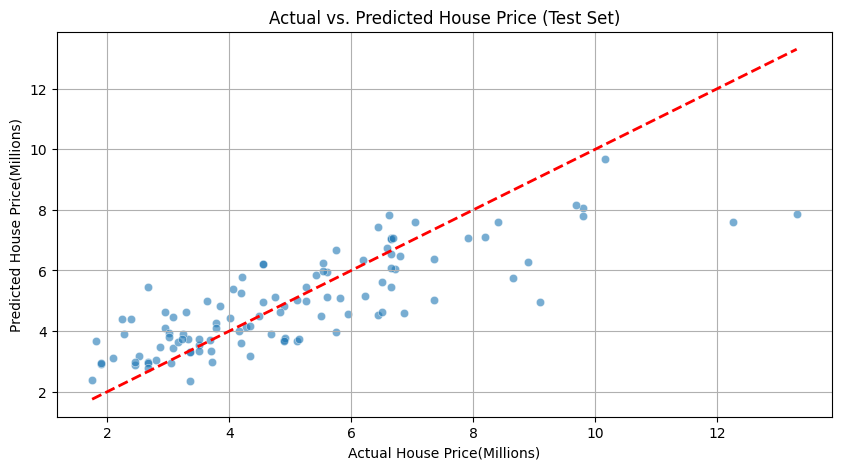

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(x=y_test/1e6, y=y_pred_test/1e6, alpha=0.6)
plt.plot([y_test.min()/1e6, y_test.max()/1e6], [y_test.min()/1e6, y_test.max()/1e6], 'r--', lw=2)
ax.set(title='Actual vs. Predicted House Price (Test Set)', xlabel='Actual House Price(Millions)', ylabel='Predicted House Price(Millions)')
plt.grid(True)
plt.show()

CHECKING HOW WELL MY MODEL WORKS

In [ ]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test, y_pred_test)
MAE = round(MAE, 2)
print(MAE)

979112.22


In [ ]:
average_house_price = df['price'].mean()
MAE_avg = (MAE / average_house_price) * 100
print(round(MAE_avg, 2))

20.54


This tells us that, on average, our model predicts house prices within 21% of the actual price.


In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_pred)
r2_test = r2_score(y_test, y_pred_test)

print(f"R2_TRAIN -> {round(r2_train, 2)}")
print(f"R2_TEST -> {round(r2_test, 2)}")

R2_TRAIN -> 0.68
R2_TEST -> 0.64


**Interpretation:**

*   **0.0 - 0.3:** Very low or no linear relationship.
*   **0.3 - 0.5:** Weak linear relationship.
*   **0.5 - 0.7:** Moderate linear relationship.
*   **0.7 - 1.0:** Strong linear relationship.

In [ ]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

importance['Coefficient'] = importance['Coefficient'].round(0).astype(int)

importance = importance.sort_values(by='Coefficient', ascending=False)

display(importance)

,Feature,Coefficient
2,bathrooms,1109326
9,airconditioning,808415
8,hotwaterheating,712265
10,prefarea,636788
7,basement,435005
3,stories,426910
5,mainroad,412678
4,parking,247443
6,guestroom,243606
1,bedrooms,78484


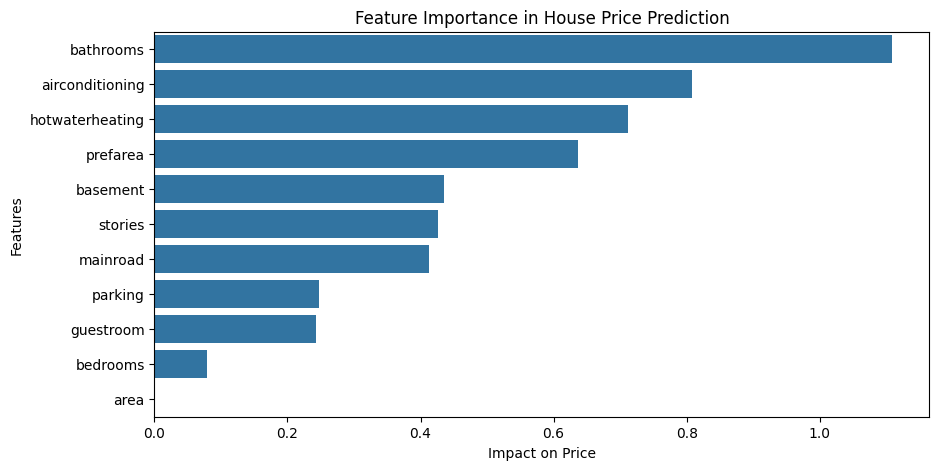

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.barplot(data=importance, x=importance['Coefficient']/1e6, y='Feature')
ax.set(title='Feature Importance in House Price Prediction', xlabel='Impact on Price', ylabel='Features')
plt.show()

**RESIDUALS** HELPS TO SHOW HOW WRONG THE MODEL IS AND WHETHER THE ERRORS ARE RANDOM.

Residuals = Actual − Predicted

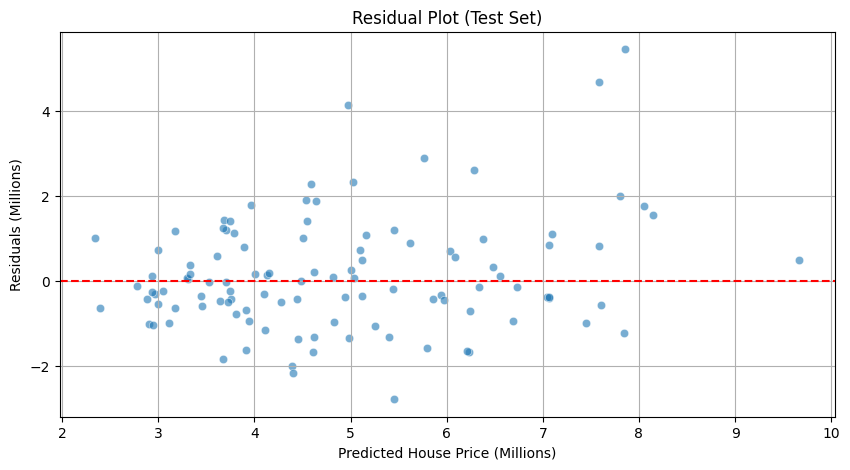

In [ ]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10,5))

ax = sns.scatterplot(x=y_pred_test/1e6, y=residuals/1e6, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

ax.set(
    title='Residual Plot (Test Set)',
    xlabel='Predicted House Price (Millions)',
    ylabel='Residuals (Millions)'
)

plt.grid(True)
plt.show()

**Meaning:**

* Model errors are random
* Model assumptions are valid